In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizer

In [2]:
# ==== Settings ====
image_size = 128
batch_size = 16
epochs = 5
timesteps = 1000
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

In [3]:
# ==== Text Embedding (DistilBERT) ====
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
bert_model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [4]:
def get_text_embedding(text):
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        output = bert_model(**tokens)
    return output.last_hidden_state.mean(dim=1)  # [batch, 768]

In [5]:
class PosterDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_filename = f"{idx + 1}.jpg"
        image_path = os.path.join(self.image_dir, image_filename)
        image = read_image(image_path).float() / 255.0  # [0,1]
        if image.dim() == 2:  # Handle grayscale images (if any)
            image = image.unsqueeze(0).repeat(3, 1, 1)  # Convert to 3 channels
        elif image.dim() == 3 and image.size(0) == 1:  # In case of single channel images
            image = image.repeat(3, 1, 1)  # Convert to 3 channels

        if self.transform:
            image = self.transform(image)
        
        text = f"{row['Title']}. {row['Description']}"
        # Fix: Pass text as a list to create a batch of size 1
        text_embed = get_text_embedding([text]).squeeze(0)  # Now correctly squeezes batch dim
        
        return image, text_embed

transform = T.Compose([
    T.ToPILImage(),  # Convert tensor to PIL image
    T.Resize((image_size, image_size)),
    T.ToTensor(),    # Convert back to tensor
])

dataset = PosterDataset('metadata.csv', 'resized_posters', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [6]:
# ==== Noise Scheduler ====
betas = torch.linspace(1e-4, 0.02, timesteps)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

def get_noisy_image(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_hat = alpha_hat[t].sqrt()[:, None, None, None]
    sqrt_one_minus_alpha_hat = (1 - alpha_hat[t]).sqrt()[:, None, None, None]
    return sqrt_alpha_hat * x0 + sqrt_one_minus_alpha_hat * noise, noise

In [7]:
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.conv = nn.Conv2d(in_channels + cond_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.norm = nn.BatchNorm2d(out_channels)

    def forward(self, x, cond):
        # Reshape cond to match spatial dimensions
        cond = cond.unsqueeze(2).unsqueeze(3)  # shape: [batch_size, cond_dim, 1, 1]
        cond = cond.expand(-1, -1, x.size(2), x.size(3))  # Expand to [batch_size, cond_dim, height, width]
        x = torch.cat([x, cond], dim=1)  # Concatenate image and condition along channels
        x = self.conv(x)
        x = self.relu(x)
        x = self.norm(x)
        return x

In [8]:
class ConditionalUNet(nn.Module):
    def __init__(self, cond_dim=768):
        super().__init__()

        # Input channels are just image channels (3)
        self.down1 = Block(3, 64, cond_dim)
        self.pool1 = nn.MaxPool2d(2)

        # Input channels now match output from previous block
        self.down2 = Block(64, 128, cond_dim)
        self.pool2 = nn.MaxPool2d(2)

        self.mid = Block(128, 128, cond_dim)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        # 64 from up1 + 128 from skip connection = 192
        self.up_block1 = Block(192, 64, cond_dim)
        self.up2 = nn.ConvTranspose2d(64, 3, 2, stride=2)

    def forward(self, x, cond, t=None):
        # No preprocessing of condition here - Block handles it
        
        # Down path
        x1 = self.down1(x, cond)
        x2 = self.down2(self.pool1(x1), cond)
        x3 = self.mid(self.pool2(x2), cond)

        # Up path with skip connections
        x = self.up1(x3)
        x = self.up_block1(torch.cat([x, x2], dim=1), cond)
        x = self.up2(x)
        return x

In [9]:
# ==== Training ====
model = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# hna fin wslt m3a claude fl convertsation, pass this cell

In [10]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for x, cond in dataloader:
        x = x.to(device)
        cond = cond.to(device)
        
        # Randomly sample a timestep
        t = torch.randint(0, timesteps, (x.size(0),), device=device).long()
        
        # Get noisy images and noise for training
        noisy_x, noise = get_noisy_image(x, t)
        
        # Forward pass through the model
        noise_pred = model(noisy_x, cond)
        
        # Compute loss (MSE between predicted noise and actual noise)
        loss = F.mse_loss(noise_pred, noise)
        
        # Zero gradients, perform backward pass, and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Log the average loss for the epoch
    print(f"Epoch {epoch+1} Loss: {running_loss / len(dataloader):.4f}")


Epoch 1 Loss: 2.2865
Epoch 2 Loss: 1.6329
Epoch 3 Loss: 1.2789
Epoch 4 Loss: 1.1834
Epoch 5 Loss: 1.1104


In [ ]:
torch.save(model.state_dict(), f"checkpoint_epoch{epoch+1}.pkl")

In [ ]:
@torch.no_grad()
def sample(model, title, description, genre, n=1):
    model.eval()
    text = f"{title}. {description}. Genre: {genre}"
    cond = get_text_embedding(text).repeat(n, 1)
    x = torch.randn((n, 3, image_size, image_size), device=device)
    for t in reversed(range(timesteps)):
        t_tensor = torch.tensor([t] * n, device=device)
        beta_t = betas[t].to(device)
        alpha_t = alphas[t].to(device)
        alpha_hat_t = alpha_hat[t].to(device)

        noise_pred = model(x, cond)
        x = (1 / alpha_t.sqrt()) * (x - ((1 - alpha_t) / (1 - alpha_hat_t).sqrt()) * noise_pred)
        if t > 0:
            noise = torch.randn_like(x)
            x += beta_t.sqrt() * noise
    return x


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1076.7198..992.7494].


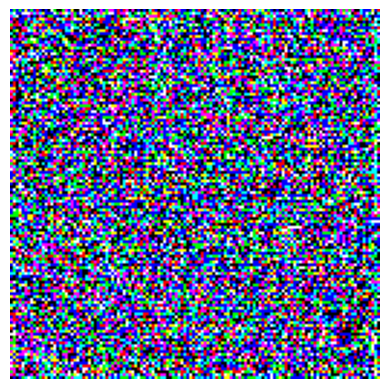

In [ ]:
generated = sample(
    model,
    title="Neo City Noir",
    description="A detective investigates a strange murder in a futuristic city",
    genre="Sci-Fi",
    n=1
)
plt.imshow(generated[0].permute(1, 2, 0))
plt.axis('off')
plt.show()